## Email intent visualization

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
annot_output = pd.read_csv('../../annotation/email_understanding/annotation_output/full/agree_df.csv')

In [3]:
annot_output

,Unnamed: 0,instance_id,scores_Act:::Thank you/Welcome,users_Act:::Thank you/Welcome,scores_num_Act:::Thank you/Welcome,label_Act:::Thank you/Welcome,statement_Act:::Thank you/Welcome,dimension_Act:::Thank you/Welcome,scores_Act:::Commit/Agree,users_Act:::Commit/Agree,...,group1,group2,group3,group4,stratum,from_trees,id,cleaned_text,batch,split
0,0,1_0,"[0.0, 0.0]","['huashen@umich.edu', 'sushrita@umich.edu']",2,0,Act:::Thank you/Welcome,Act:::Thank you/Welcome,"[0.0, 0.0]","['huashen@umich.edu', 'sushrita@umich.edu']",...,linux,lfs,clfs,support,0,True,1_0,Re: Cannot find bcopy() \n <quotation> symbol...,1,test
1,1,1_1,"[0.0, 0.0]","['isabrah@umich.edu', 'bowenyi@umich.edu']",2,0,Act:::Thank you/Welcome,Act:::Thank you/Welcome,"[0.0, 0.0]","['isabrah@umich.edu', 'bowenyi@umich.edu']",...,comp,python,python-3000,devel,10,True,1_1,Re: need help fixing broken tests in py3k-pep3...,1,train
2,2,1_10,"[0.0, 0.0, 1.0]","['elisazmq@umich.edu', 'isabrah@umich.edu', 'a...",3,1,Act:::Thank you/Welcome,Act:::Thank you/Welcome,"[0.0, 0.0, 0.0]","['elisazmq@umich.edu', 'isabrah@umich.edu', 'a...",...,comp,handhelds,openmoko,community,1,True,1_10,errors using mdbus commands \n I'm having some...,1,train
3,3,1_11,"[0.0, 0.0, 0.0]","['zht@umich.edu', 'leczhang@umich.edu', 'mjjia...",3,0,Act:::Thank you/Welcome,Act:::Thank you/Welcome,"[0.0, 0.0, 0.0]","['zht@umich.edu', 'leczhang@umich.edu', 'mjjia...",...,comp,mozilla,devel,webtools,10,True,1_11,Re: Adding test case to test run gives error \...,1,train
4,4,1_12,[0.0],['nancyxuyinuo@gmail.com'],1,0,Act:::Thank you/Welcome,Act:::Thank you/Welcome,[0.0],['nancyxuyinuo@gmail.com'],...,linux,ubuntu,user,NaN,1,True,1_12,Re: HP 4P scanner use \n Thanks to Brian McKee...,1,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635,1635,2_992,[0.0],['zht@umich.edu'],1,0,Act:::Thank you/Welcome,Act:::Thank you/Welcome,[0.0],['zht@umich.edu'],...,os,ecos,general,NaN,0,True,2_992,PowerPC platform compilation errors \n <saluta...,2,test
1636,1636,2_995,[1.0],['bowenyi@umich.edu'],1,1,Act:::Thank you/Welcome,Act:::Thank you/Welcome,[0.0],['bowenyi@umich.edu'],...,comp,python,django,user,11,True,2_995,Re: Can you add custom logic to the Admin page...,2,test
1637,1637,2_996,[0.0],['sushrita@umich.edu'],1,0,Act:::Thank you/Welcome,Act:::Thank you/Welcome,[0.0],['sushrita@umich.edu'],...,os,freebsd,devel,alpha,dev1,False,2_996,Re: 5.0-RC2 on Alphaserver 4100 mostly a succe...,2,test
1638,1638,2_998,[0.0],['zht@umich.edu'],1,0,Act:::Thank you/Welcome,Act:::Thank you/Welcome,[0.0],['zht@umich.edu'],...,network,cspace,user,NaN,0,True,2_998,Re: Friendslist CSpace as a Firefox extension ...,2,train


In [59]:
def graph_dist(group_by_col, df, title_text, xlabel_text, ylabel_text, fig_name):
    
    '''
    Group annotation output by group_by_col and calculate percentage of group_by_col in each
    of the 5 categories of email intent acts. Then visualize the distribution as stacked bar graph.
    
    inputs:
        - group_by_col (str): column to groupby
        - df: annotation output dataframe
        - title_text (str), xlabel_text(str), ylabel_text(str), fig_name(str)
        
    outputs:
        - None, the figure is saved to fig_name
    
    '''
    
    df_filtered = df[list(df.filter(regex='label_Act').columns) +[group_by_col]]  
    df_result = df_filtered.groupby(group_by_col).sum()
   
    df_result.columns = ['Thank you/Welcome', 'Commit/Agree', 'Request', 'Deliver/Informative',  'Other']
    
    df_result_norm = df_result.div(df_result.sum(axis=1), axis=0).reset_index()
    
   
    df_result_norm.plot( 
        x = group_by_col, 
        kind = 'barh', 
        stacked = True, 
        title = title_text, 
        color = ['mediumpurple', 'lightsteelblue', 'pink', 'yellowgreen', 'khaki',
#                  'mediumpurple', 'silver', 'lightsteelblue', 'tomato'
                ],
        mark_right = True) 

    plt.xlabel(xlabel_text)
    plt.ylabel(ylabel_text)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),  ncol=3)
    plt.savefig(fig_name,bbox_inches='tight')
    plt.show()
    


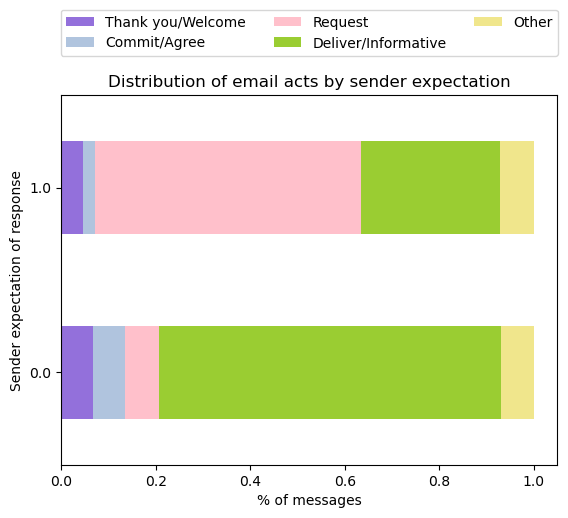

In [60]:
graph_dist('label_Sender Expectation', annot_output, 'Distribution of email acts by sender expectation', '% of messages', 'Sender expectation of response', '../visualizations/dist_acts_expectation.png') 

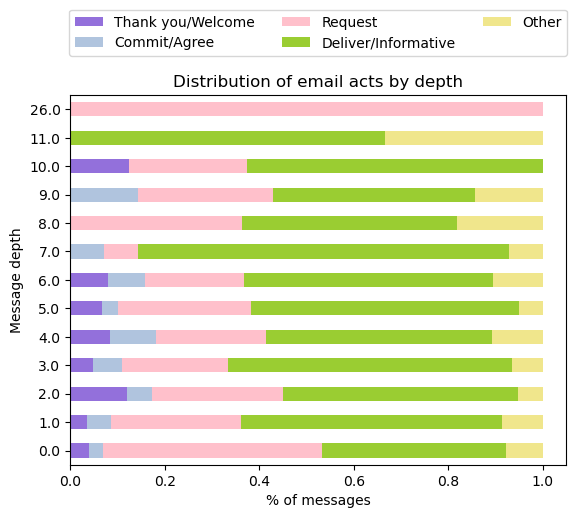

In [61]:
graph_dist('message_depth', annot_output, 'Distribution of email acts by depth', '% of messages', 'Message depth', '../visualizations/dist_acts_depth.png') 

